In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append('..')
os.chdir('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

## Load TV Checkpoint

After running `python reg_cob.py +tv_experiment=1d_tv`, a checkpoint folder is created at
`outputs/checkpoints/<run-name>/`.  Set `CKPT_DIR` and `CKPT_FILE` below.

In [57]:
%autoreload 2
import yaml
from omegaconf import OmegaConf
from hydra.utils import instantiate
from infidictionary.neural_isometries import NeuralIsometry
from infidictionary.dictionaries import InfiDictionary

# CKPT_DIR  = "outputs/checkpoints/wandb-mf74ud6o"   # <-- Fourier field initialization (high frequency)
# CKPT_FILE = "step_60.pt"                         

# CKPT_DIR  = "outputs/checkpoints/wandb-mr2pjiya"   # <-- training for a long time with the NewTimeEvolvingField architecture
# CKPT_FILE = "step_1460.pt"

# CKPT_DIR  = "outputs/checkpoints/wandb-g3y07yx0"   # <-- training with the simple FullSpectrum architecture
# CKPT_FILE = "step_70.pt"

# CKPT_DIR  = "outputs/checkpoints/wandb-uzsf4ddj"   # <-- training with the simple FullSpectrum architecture
# CKPT_FILE = "step_12200.pt"


# CKPT_DIR  = "outputs/checkpoints/wandb-nljoqvpa"   # <-- distortion field + expressive field [learnable distortion]
# CKPT_FILE = "step_590.pt"


CKPT_DIR  = "outputs/checkpoints/wandb-pf3ka34u"   # <-- distortion field + expressive field [learnable distortion + gamma tuned]
CKPT_FILE = "step_8120.pt"

# CKPT_DIR  = "outputs/checkpoints/wandb-ngv0204e"   # <-- detach(distortion field) + expressive field [fixed distortion]
# CKPT_FILE = "step_590.pt"


CKPT_DIR  = "outputs/checkpoints/wandb-8r2ec3ye"   # <-- DistortedField V2
CKPT_FILE = "step_590.pt"




with open(f"{CKPT_DIR}/config.yaml") as f:
    conf = OmegaConf.create(yaml.safe_load(f))

isometry:   NeuralIsometry  = instantiate(conf.neural_isometry).to(device)
dictionary: InfiDictionary  = instantiate(conf.initial_dictionary)

ckpt = torch.load(f"{CKPT_DIR}/{CKPT_FILE}", map_location=device, weights_only=False)
isometry.load_state_dict(ckpt["models"]["neural_isometry"])

model_state_kwargs = dict(conf.get("model_state_kwargs", {"num_steps": 50}))
pushforward_kwargs = dict(conf.get("pushforward_kwargs", {"start_time": 0.0, "end_time": 1.0}))
model_state_kwargs["num_steps"] = 50 # 400

isometry.shuffle_model_state(**model_state_kwargs)
isometry.eval()

print(f"Loaded : {CKPT_DIR}/{CKPT_FILE}  (epoch {ckpt['epoch']})")
print(f"Metric : {ckpt['metric']:.6f}  |  best: {ckpt['best_metric']:.6f}")

Loaded : outputs/checkpoints/wandb-8r2ec3ye/step_590.pt  (epoch 589)
Metric : 0.006626  |  best: 0.005824


## Evaluate Fourier Atoms and their Pushforward

- `NUM_TRUNCATED` controls the frequency range: atoms for $k \in \{-(K-1),\dots,K-1\}$.
- Coords are sorted so the line plots are smooth.

In [58]:
from infidictionary.domain_samplers import LineSegmentSampler

N_VIZ         = 500
NUM_TRUNCATED = 6# 2   # frequencies k in {-(K-1), ..., K-1}

# Dense, evenly-spaced 1-D grid on [0, 1]
coords    = LineSegmentSampler(stratified=False, add_noise=False).sample(N_VIZ).to(device)  # (N, 1)
logabsdet = torch.zeros(N_VIZ, device=device)

# Sort by x so line plots are clean
order     = coords[:, 0].argsort()
coords    = coords[order]
logabsdet = logabsdet[order]

# Index tensor shape: (A, 2) where columns are [k, channel]
indices = dictionary.get_truncated_indices(num_truncated=NUM_TRUNCATED).to(device)
idx_np  = indices.cpu().numpy()
print(f"Indices: {indices.shape}  (k range {idx_np[:, 0].min()} to {idx_np[:, 0].max()})")

with torch.no_grad():
    atoms = dictionary.get_atoms(coords, indices)          # (A, N, 1)
    isometry.shuffle_model_state(**model_state_kwargs)
    _, _, deformed = isometry.pushforward(
        src_coords=coords,
        src_logabsdet=logabsdet,
        src_field=atoms,
        **pushforward_kwargs,
    )                                                      # (A, N, 1)

atoms_np    = atoms.cpu().numpy()    # (A, N, 1)
deformed_np = deformed.cpu().numpy() # (A, N, 1)
xs          = coords[:, 0].cpu().numpy()

print(f"atoms:    {atoms_np.shape}")
print(f"deformed: {deformed_np.shape}")

Indices: torch.Size([11, 2])  (k range -5 to 5)
atoms:    (11, 500, 1)
deformed: (11, 500, 1)


## Plot: Fourier Atoms vs. TV-Regularised Pushforward

- **Top row** — original Fourier atoms $\phi_k(x)$  
- **Bottom row** — TV-regularised modes $(Q\phi_k)(x)$  

Columns are labelled by the signed frequency index $k$.

## Visualise the Neural Field $v(t, x)$

The `EulerianIsometry` rotates function values via a sequence of Householder reflections
driven by `function_field(t, x)`.  Here we sweep over a dense $(t, x)$ grid and plot
$v(t, x)$ as a heatmap — x on the horizontal axis, t on the vertical axis.

/tmp/ipykernel_1245474/1604216209.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


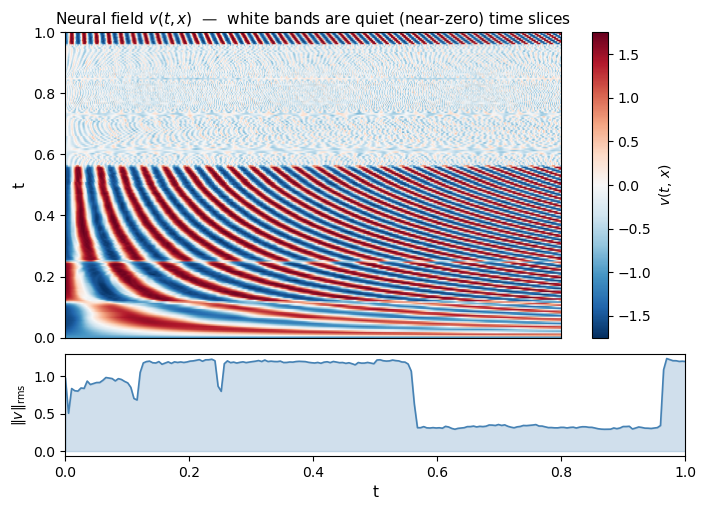

In [59]:
N_T = 200   # resolution along the time axis
N_X = 500   # resolution along the spatial axis

t_vals = torch.linspace(0.0, 1.0, N_T, device=device, dtype=torch.get_default_dtype())
x_vals = torch.linspace(0.0, 1.0, N_X, device=device, dtype=torch.get_default_dtype())

t_grid = t_vals.repeat_interleave(N_X)       # (N_T * N_X,)
x_grid = x_vals.repeat(N_T).unsqueeze(-1)    # (N_T * N_X, 1)

with torch.no_grad():
    v_grid = isometry.function_field(t_grid, x_grid)  # (N_T * N_X, C)

v_np  = v_grid[:, 0].cpu().numpy().reshape(N_T, N_X)  # (N_T, N_X)
t_np  = t_vals.cpu().numpy()

# RMS norm over x at each t: shows how "active" the field is at each time slice
v_rms = np.sqrt((v_np ** 2).mean(axis=1))   # (N_T,)

fig, (ax_map, ax_norm) = plt.subplots(
    2, 1, figsize=(8, 5.5),
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.08},
)

# ── Heatmap ───────────────────────────────────────────────────────────────────
vmax = np.abs(v_np).max() + 1e-8
im = ax_map.imshow(
    v_np,
    origin="lower",
    aspect="auto",
    extent=[0, 1, 0, 1],
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
plt.colorbar(im, ax=ax_map, label=r"$v(t,\, x)$")
ax_map.set_ylabel("t", fontsize=11)
ax_map.set_xticks([])
ax_map.set_title(
    r"Neural field $v(t, x)$  —  white bands are quiet (near-zero) time slices",
    fontsize=11,
)

# ── RMS norm over x ───────────────────────────────────────────────────────────
ax_norm.plot(t_np, v_rms, color="steelblue", lw=1.2)
ax_norm.fill_between(t_np, v_rms, alpha=0.25, color="steelblue")
ax_norm.set_xlabel("t", fontsize=11)
ax_norm.set_ylabel(r"$\|v\|_{\mathrm{rms}}$", fontsize=10)
ax_norm.set_xlim(0, 1)

plt.tight_layout()
plt.show()

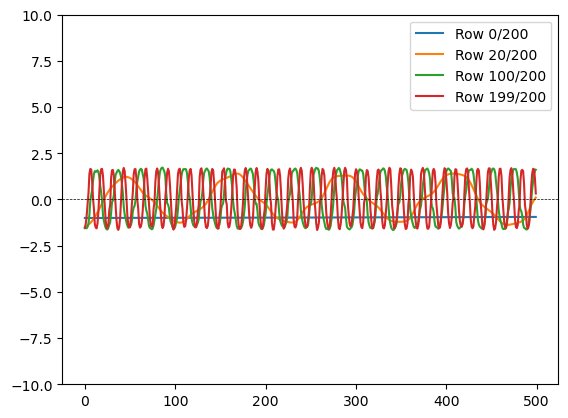

: 

In [ ]:
rows_frac = np.array([0.0, 0.1, 0.5, 1.0]) #, 1.0])
# rows_frac = np.array([0.1, 0.2, 0.6]) #, 1.0])
# now plot multiple rows
for i in range(len(rows_frac)):
    row_idx = min(max(0, (rows_frac[i] * v_np.shape[0]).astype(int)), v_np.shape[0]-1)
    row = v_np[row_idx, :]
    plt.plot(np.arange(row.shape[0]), row, label=f"Row {row_idx}/{v_np.shape[0]}")
plt.ylim(-10, 10)
# plot the zero axis
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.show()

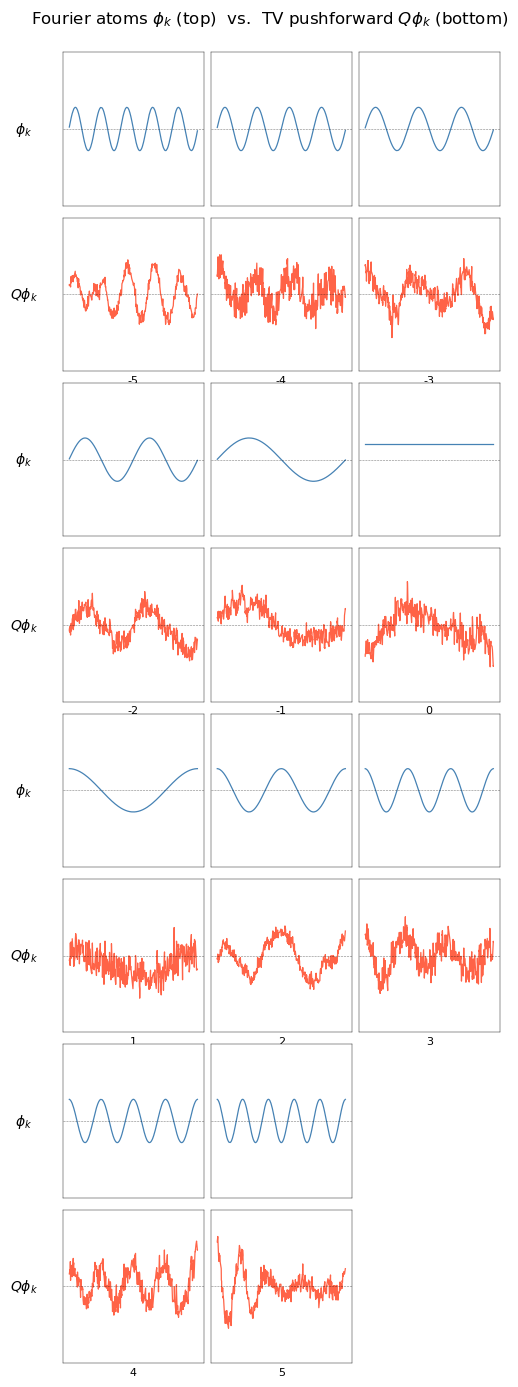

In [61]:
# Keep only channel-0 atoms; build a k -> atom-row lookup
k_vals   = sorted(set(int(v) for v in idx_np[:, 0]))
k_lookup = {
    int(idx_np[i, 0]): i
    for i in range(len(idx_np))
    if int(idx_np[i, -1]) == 0
}

N_COLS = 3     # atoms per row of the figure
TILE_W = 1.6
TILE_H = 1.8

# Split k_vals into chunks of N_COLS; each chunk becomes one pair of rows
chunks   = [k_vals[i:i + N_COLS] for i in range(0, len(k_vals), N_COLS)]
n_chunks = len(chunks)

# 2 subplot-rows per chunk (Fourier on top, pushforward below)
fig, axes = plt.subplots(
    n_chunks * 2, N_COLS,
    figsize=(N_COLS * TILE_W, n_chunks * 2 * TILE_H),
    gridspec_kw={"hspace": 0.08, "wspace": 0.05},
    squeeze=False,
)
fig.subplots_adjust(left=0.07, right=0.98, bottom=0.04, top=0.95)

row_labels = [r"$\phi_k$", r"$Q\phi_k$"]
row_colors = ["steelblue", "tomato"]

for chunk_i, chunk_ks in enumerate(chunks):
    for ci_local, k in enumerate(chunk_ks):
        for row_offset, (arr, color, row_lbl) in enumerate(
            zip([atoms_np, deformed_np], row_colors, row_labels)
        ):
            ax = axes[chunk_i * 2 + row_offset, ci_local]
            if k in k_lookup:
                i = k_lookup[k]
                ax.plot(xs, arr[i, :, 0], lw=0.9, color=color)
                ax.axhline(0, color="k", lw=0.4, ls="--", alpha=0.5)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_ylim(-5, 5)
            for spine in ax.spines.values():
                spine.set_linewidth(0.3)

            if row_offset == 1:
                ax.set_xlabel(str(k), fontsize=8, labelpad=3)
            if ci_local == 0:
                ax.set_ylabel(row_lbl, fontsize=10, rotation=0, labelpad=28, va="center")

    # Hide unused tiles in the last chunk
    for ci_local in range(len(chunk_ks), N_COLS):
        for row_offset in range(2):
            axes[chunk_i * 2 + row_offset, ci_local].set_visible(False)

fig.suptitle(
    r"Fourier atoms $\phi_k$ (top)  vs.  TV pushforward $Q\phi_k$ (bottom)",
    fontsize=12,
)
plt.show()